<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/filas/filas_caminhao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("base_ficticia_centro_distribuicao_200_caminhoes.xlsx")

df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,id_caminhao,data_operacao,dia_semana,periodo_chegada,tipo_operacao,tipo_carga,prioridade,transportadora,origem_destino,doca_tipo,...,tempo_carregamento_min,tempo_atendimento_total_min,tempo_espera_observado_min,tempo_total_sistema_min,sla_max_min,atendeu_sla,custo_espera_por_min,custo_espera_total,status_operacao,observacoes
0,CAM-0001,2026-04-07,terça-feira,Madrugada,Recebimento,Eletrônicos,Normal,Rápido Norte,Macaé → Loja Pelinca,Mista,...,0,75,32,107,90,Não,3.88,124.16,Concluída,Atraso por fila
1,CAM-0002,2026-04-06,segunda-feira,Tarde,Recebimento,Bebidas,Normal,Nova Rota,Macaé → Cliente Norte,Mista,...,0,68,4,72,90,Sim,4.50,18.00,Concluída,Aguardando conferência
2,CAM-0003,2026-04-15,quarta-feira,Tarde,Recebimento,Alimentos,Normal,Litoral Log,Rio de Janeiro → Supermercado Parceiro,Mista,...,0,81,49,130,90,Não,3.15,154.35,Concluída,Sem ocorrência
3,CAM-0004,2026-04-07,terça-feira,Meio-dia,Expedição,Alimentos,Normal,Rápido Norte,Niterói → Supermercado Parceiro,Mista,...,25,37,32,69,90,Sim,2.97,95.04,Concluída,Sem ocorrência
4,CAM-0005,2026-04-09,quinta-feira,Meio-dia,Devolução,Limpeza,Normal,LogMais,Cabo Frio → CD Campos,Seca,...,0,38,75,113,90,Não,2.31,173.25,Concluída,Atraso por fila


In [ ]:
df.isnull().sum()

,0
id_caminhao,0
data_operacao,0
dia_semana,0
periodo_chegada,0
tipo_operacao,0
tipo_carga,0
prioridade,0
transportadora,0
origem_destino,0
doca_tipo,0


In [ ]:
colunas_numericas = ["volume_pallets", "tempo_atendimento_total_min", "tempo_espera_observado_min", "tempo_total_sistema_min", "custo_espera_total"]

In [ ]:
df[colunas_numericas].describe()

,volume_pallets,tempo_atendimento_total_min,tempo_espera_observado_min,tempo_total_sistema_min,custo_espera_total
count,200.000000,200.00000,200.000000,200.000000,200.000000
mean,15.200000,57.12500,33.015000,90.140000,127.111400
std,5.892675,15.10597,20.830852,26.600533,94.453724
min,2.000000,25.00000,0.000000,32.000000,0.000000
25%,11.750000,45.75000,18.500000,72.000000,56.565000
50%,15.000000,56.00000,32.000000,87.500000,113.170000
75%,19.000000,67.25000,47.000000,107.250000,185.685000
max,31.000000,104.00000,85.000000,157.000000,464.340000


In [ ]:
df["tipo_operacao"].value_counts(normalize=True) * 100

,proportion
tipo_operacao,
Recebimento,48.0
Expedição,45.0
Devolução,7.0


In [ ]:
df.groupby("tipo_operacao")[["tempo_atendimento_total_min", "tempo_espera_observado_min", "tempo_total_sistema_min", "custo_espera_total"]].mean()

,tempo_atendimento_total_min,tempo_espera_observado_min,tempo_total_sistema_min,custo_espera_total
tipo_operacao,,,,
Devolução,61.785714,35.428571,97.214286,122.145000
Expedição,51.233333,34.533333,85.766667,135.412333
Recebimento,61.968750,31.239583,93.208333,120.053542


In [ ]:
df["prioridade"].value_counts()

,count
prioridade,
Normal,143
Perecível,30
Urgente,27


In [ ]:
df.groupby("prioridade")[["tempo_atendimento_total_min", "tempo_espera_observado_min", "tempo_total_sistema_min", "custo_espera_total"]].mean()

,tempo_atendimento_total_min,tempo_espera_observado_min,tempo_total_sistema_min,custo_espera_total
prioridade,,,,
Normal,56.902098,32.650350,89.552448,116.452098
Perecível,55.300000,44.900000,100.200000,212.512000
Urgente,60.333333,21.740741,82.074074,88.676667


In [ ]:
df["sla_max_min"].value_counts()

,count
sla_max_min,
90,143
60,30
70,27


In [ ]:
df["sla_max_min"].value_counts(normalize=True) * 100

,proportion
sla_max_min,
90,71.5
60,15.0
70,13.5


In [ ]:
df.groupby("tipo_operacao")["atendeu_sla"].apply(lambda x: x.map({'Sim': 1, 'Não': 0}).mean()) * 100

,atendeu_sla
tipo_operacao,
Devolução,28.571429
Expedição,52.222222
Recebimento,41.666667


In [ ]:
df.groupby("prioridade")["atendeu_sla"].apply(lambda x: x.map({'Sim': 1, 'Não': 0}).mean()) * 100

,atendeu_sla
prioridade,
Normal,55.944056
Perecível,3.333333
Urgente,37.037037


In [ ]:
df['hora_chegada_dt'] = pd.to_datetime(df['hora_chegada'], format='%H:%M')
df['hora_chegada_dt'] = df['hora_chegada_dt'].dt.time

In [ ]:
chegadas_por_hora = df['hora_chegada_dt'].apply(lambda x: x.hour).value_counts().sort_index()

chegadas_por_hora


,count
hora_chegada_dt,
6,7
7,5
8,25
9,32
10,30
11,13
12,9
13,15
14,13


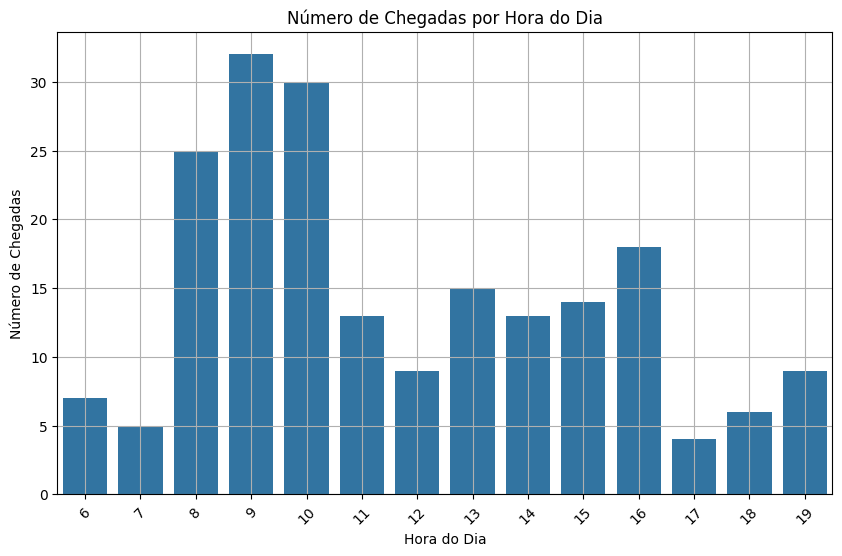

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=chegadas_por_hora.index, y=chegadas_por_hora.values)
plt.grid(True)
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Chegadas')
plt.title('Número de Chegadas por Hora do Dia')
plt.xticks(rotation=45)
plt.show()

In [ ]:
tempo_espera_por_hora = df.groupby(df['hora_chegada_dt'].apply(lambda x: x.hour))['tempo_espera_observado_min'].mean()

In [ ]:
tempo_espera_por_hora

,tempo_espera_observado_min
hora_chegada_dt,
6,12.571429
7,10.200000
8,46.000000
9,43.031250
10,46.166667
11,27.153846
12,26.888889
13,29.133333
14,26.307692


Text(0.5, 1.0, 'Tempo Esperado Médio por Hora do Dia')

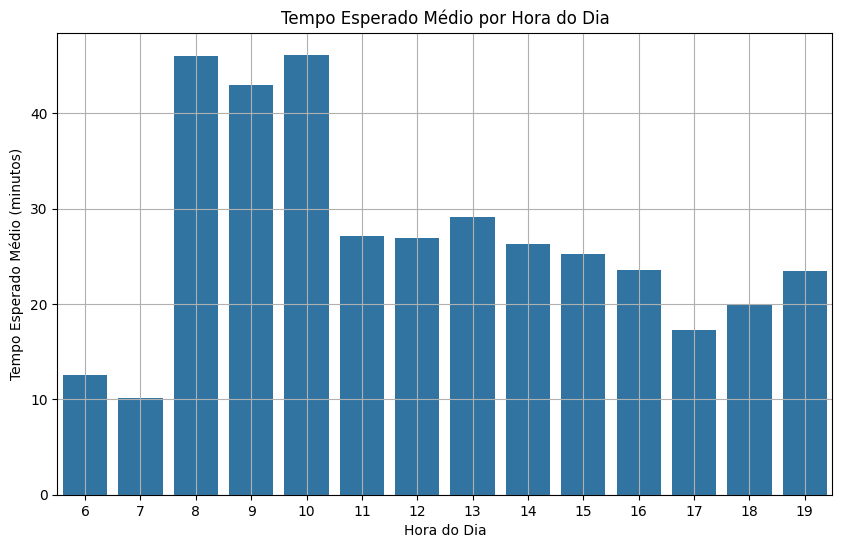

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=tempo_espera_por_hora.index, y=tempo_espera_por_hora.values)
plt.grid(True)
plt.xlabel('Hora do Dia')
plt.ylabel('Tempo Esperado Médio (minutos)')
plt.title('Tempo Esperado Médio por Hora do Dia')

In [ ]:
custo_total = df["custo_espera_total"].sum()

print(f"custo total: R$ {custo_total:.2f}")

custo total: R$ 25422.28


In [ ]:
custo_medio = df["custo_espera_total"].mean()

print(f"custo médio por caminhão: R$ {custo_medio:.2f}")

custo médio por caminhão: R$ 127.11


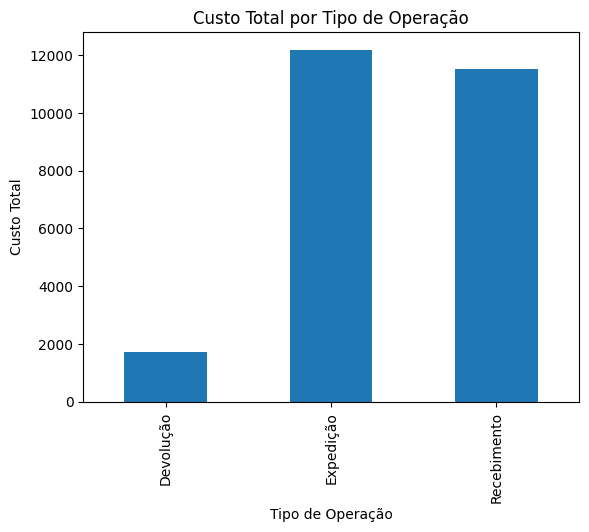

In [ ]:
df.groupby("tipo_operacao")["custo_espera_total"].sum().plot(kind="bar")
plt.xlabel("Tipo de Operação")
plt.ylabel("Custo Total")
plt.title("Custo Total por Tipo de Operação")
plt.show()

In [ ]:
resumo_operacao1 = df.groupby("tipo_operacao").agg(quantidade_caminhoes=("id_caminhao", "count"),
                                                  espera_media_min=("tempo_espera_observado_min", "mean"),
                                                  atendimento_medio_min=("tempo_atendimento_total_min", "mean"),
                                                  tempo_total_medio_min=("tempo_total_sistema_min", "mean"),
                                                  custo_total_espera=("custo_espera_total", "sum"),
                                                  atendeu_sla_porcentagem=("atendeu_sla", lambda x: (x == "Sim").mean() * 100))

resumo_operacao1

,quantidade_caminhoes,espera_media_min,atendimento_medio_min,tempo_total_medio_min,custo_total_espera,atendeu_sla_porcentagem
tipo_operacao,,,,,,
Devolução,14,35.428571,61.785714,97.214286,1710.03,28.571429
Expedição,90,34.533333,51.233333,85.766667,12187.11,52.222222
Recebimento,96,31.239583,61.968750,93.208333,11525.14,41.666667


In [ ]:
resumo_operacao2 = df.groupby("prioridade").agg(quantidade_caminhoes=("id_caminhao", "count"),
                                                  espera_media_min=("tempo_espera_observado_min", "mean"),
                                                  atendimento_medio_min=("tempo_atendimento_total_min", "mean"),
                                                  tempo_total_medio_min=("tempo_total_sistema_min", "mean"),
                                                  custo_total_espera=("custo_espera_total", "sum"),
                                                  atendeu_sla_porcentagem=("atendeu_sla", lambda x: (x == "Sim").mean() * 100))

resumo_operacao2

,quantidade_caminhoes,espera_media_min,atendimento_medio_min,tempo_total_medio_min,custo_total_espera,atendeu_sla_porcentagem
prioridade,,,,,,
Normal,143,32.650350,56.902098,89.552448,16652.65,55.944056
Perecível,30,44.900000,55.300000,100.200000,6375.36,3.333333
Urgente,27,21.740741,60.333333,82.074074,2394.27,37.037037


In [ ]:
!pip install simpy